In [2]:
# In Colab: Runtime → Change runtime type → GPU

from google.colab import drive
drive.mount('/content/drive')  # optional, but useful if you want things to persist


Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Transformer_Encoder

/content/drive/MyDrive/Transformer_Encoder


In [4]:

%cd SwinBrain
!ls


/content/drive/MyDrive/Transformer_Encoder/SwinBrain
'Copy of PreProcess_SwinBrain.ipynb'   Pretrained_models
 dataset_split.json		       README.md
 Fine_tune_commented.ipynb	       requirements.txt
 finetune_test.py		       run_docker.sh
 finetune_train.py		       run_ssl_train.sh
 Models.py			       segmentation_model
 persistent_cache		       SwinUNETR_pretrain_DDP.py
 PreProcess_SwinBrain.ipynb	       workflow.jpg


In [5]:
!pip install -r requirements.txt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 130.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 149.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.

In [ ]:
!pip install hd-bet

  Using cached hd_bet-2.0.1.tar.gz (8.8 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached simpleitk-2.5.2-cp311-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (7.2 kB)
  Using cached nnunetv2-2.6.2.tar.gz (211 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:



!pip install gdown

!ls Pretrained_models


ls: cannot access 'Pretrained_models': No such file or directory


In [2]:
from pathlib import Path

RAW_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_raw")
OUT_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

RAW_ROOT, OUT_ROOT


(PosixPath('/content/drive/MyDrive/Brain_segmentation/BRATS_MET_raw'),
 PosixPath('/content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc'))

In [ ]:
# ---------------------------------------------------------
# Step 1: Find T1 & Create Brain Mask (HD-BET Bypassed)
# Assumes the raw T1 scan is already skull-stripped.
# ---------------------------------------------------------

import nibabel as nib
import numpy as np
from pathlib import Path
import subprocess
import shutil

RAW_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_raw")
OUT_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print("RAW ROOT:", RAW_ROOT)
print("OUT ROOT:", OUT_ROOT)

# Loop over cases
cases = sorted([p for p in RAW_ROOT.iterdir() if p.is_dir()])

print(f"\nFound {len(cases)} cases:", [c.name for c in cases])

for case in cases:
    case_name = case.name
    print(f"\n========== {case_name} ==========")

    # --- Flexible finder for T1 scan (handles both datasets) ---
    t1_candidates = (
        list(case.glob(f"{case_name}-t1n.nii*")) +  # For BraTS-MET
        list(case.glob(f"{case_name}_t1.nii*"))      # For BraTS2021
    )

    if not t1_candidates:
        print(f"[{case_name}] ❌ No t1n or t1 found, skipping.")
        continue

    t1_path = t1_candidates[0]

    # Output directory and files
    out_case = OUT_ROOT / case_name
    out_case.mkdir(exist_ok=True)

    out_img = out_case / "t1_brain.nii.gz"        # Standardized name
    out_mask = out_case / "t1_brain_mask.nii.gz"  # Standardized mask name

    # Skip if already done
    if out_img.exists() and out_mask.exists():
        print(f"[{case_name}] ✔ Already processed, skipping.")
        continue

    print(f"[{case_name}] Processing {t1_path.name} (HD-BET Bypassed)")

    try:
        # --- NEW LOGIC (No HD-BET) ---

        # 1. Load the raw T1 image
        raw_t1_img = nib.load(str(t1_path))
        raw_t1_data = raw_t1_img.get_fdata()

        # 2. Save it directly as t1_brain.nii.gz
        # We must use Nifti1Image to preserve the original affine and header
        brain_img = nib.Nifti1Image(raw_t1_data, raw_t1_img.affine, raw_t1_img.header)
        nib.save(brain_img, str(out_img))
        print(f"[{case_name}] ✅ Copied to {out_img.name}")

        # 3. Create the mask from this image (where voxel value > 0)
        mask_data = (raw_t1_data > 0).astype(np.uint8)
        mask_img = nib.Nifti1Image(mask_data, raw_t1_img.affine, raw_t1_img.header)
        nib.save(mask_img, str(out_mask))
        print(f"[{case_name}] ✅ Created {out_mask.name}")
        # --- END NEW LOGIC ---

    except Exception as e:
        print(f"[{case_name}] ❌ FAILED to copy or create mask: {e}")

In [ ]:
# ---------------------------------------------------------
# Strip the skull using HD-Bet T1
# ---------------------------------------------------------

!pip install -q hd-bet

from pathlib import Path
import subprocess

RAW_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_raw")
OUT_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print("RAW ROOT:", RAW_ROOT)
print("OUT ROOT:", OUT_ROOT)

def run_hdbet(in_path: Path, out_path: Path, device="cpu"):
    """
    HD-BET requires:
        -o <output.nii.gz>
    It will produce:
        output.nii.gz
        output_mask.nii.gz
    """
    cmd = [
        "hd-bet",
        "-i", str(in_path),
        "-o", str(out_path),      # MUST end with .nii.gz
        "-device", device,
        "--disable_tta",
    ]

    print("\nRunning:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print("❌ HD-BET FAILED")
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError("HD-BET failed")
    else:
        print("HD-BET completed successfully.")


# Loop over cases
cases = sorted([p for p in RAW_ROOT.iterdir() if p.is_dir()])

print(f"\nFound {len(cases)} cases:", [c.name for c in cases])

for case in cases:
    case_name = case.name
    print(f"\n========== {case_name} ==========")

    # --- THIS IS THE FIX ---
    # Flexible finder for T1 scan (prioritizes t1n, then t1)
    t1_candidates = (
        list(case.glob(f"{case_name}-t1n.nii*")) +  # For BraTS-MET
        list(case.glob(f"{case_name}_t1.nii*"))      # For BraTS2021
    )
    # --- END OF FIX ---

    if not t1_candidates:
        print(f"[{case_name}] ❌ No t1n or t1 found, skipping.")
        continue

    t1_path = t1_candidates[0]

    # Output directory and files
    out_case = OUT_ROOT / case_name
    out_case.mkdir(exist_ok=True)

    out_img = out_case / "t1_brain.nii.gz"            # required
    out_mask = out_case / "t1_brain_mask.nii.gz"      # HD-BET auto-generates this

    # Skip if already done
    if out_img.exists() and out_mask.exists():
        print(f"[{case_name}] ✔ Already skull stripped, skipping.")
        continue

    print(f"[{case_name}] Running HD-BET on {t1_path.name}")
    run_hdbet(t1_path, out_img, device="cuda")

    # Validate results
    if out_img.exists() and out_mask.exists():
        print(f"[{case_name}] ✅ Skull stripping complete.")
    else:
        print(f"[{case_name}] ❌ Output missing — check errors.")

RAW ROOT: /content/drive/MyDrive/Brain_segmentation/BRATS_MET_raw
OUT ROOT: /content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc

Found 1 cases: ['BraTS-MET-00086-000']

========== BraTS-MET-00086-000 ==========
[BraTS-MET-00086-000] ✔ Already skull stripped, skipping.


Original T1:      /content/drive/MyDrive/Brain_segmentation/BRATS_MET_raw/BraTS-MET-00086-000/BraTS-MET-00086-000-t1n.nii.gz
Skull-stripped:   /content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc/BraTS-MET-00086-000/t1_brain.nii.gz
Mask (to save):   /content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc/BraTS-MET-00086-000/t1_brain_mask.nii.gz
Mask unique values: [0 1]
Saved mask to: /content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc/BraTS-MET-00086-000/t1_brain_mask.nii.gz
Original shape:       (240, 240, 155)
Skull-stripped shape: (240, 240, 155)
Mask shape:           (240, 240, 155)


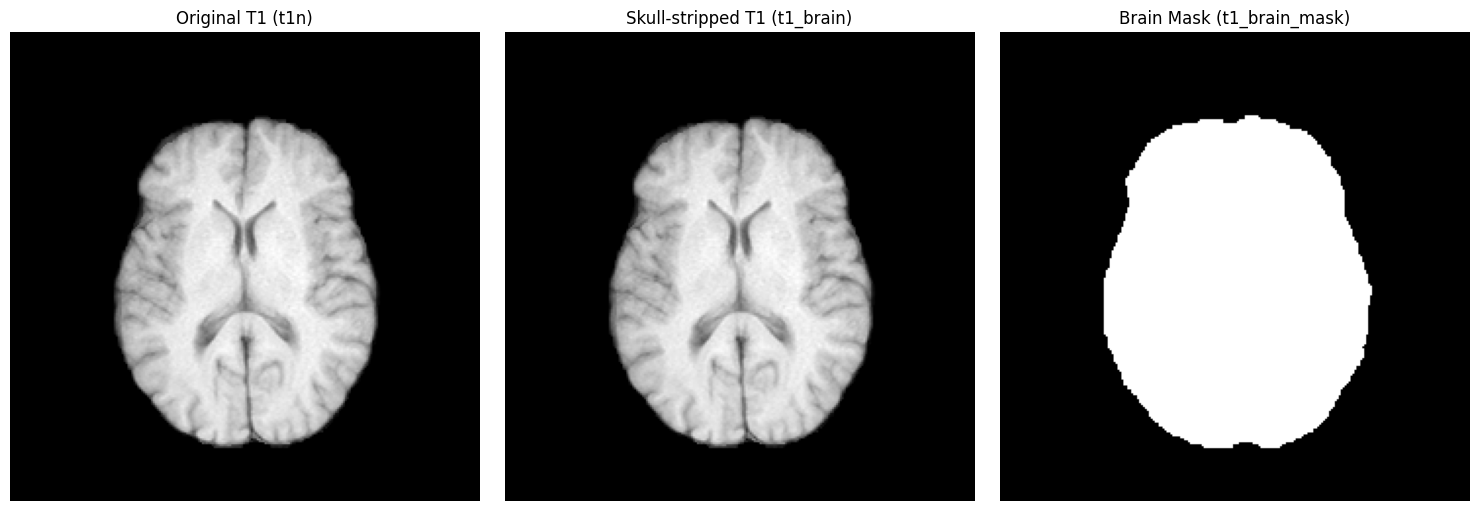

In [9]:
# ---------------------------------------------------------
# Create the mask T1
# ---------------------------------------------------------

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ----- CONFIG -----
CASE = "BraTS-MET-00086-000"  # change this to another case if you want

RAW_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_raw")
OUT_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc")

# Paths
raw_case  = RAW_ROOT / CASE
out_case  = OUT_ROOT / CASE

# --- THIS IS THE FIX ---
# Find the original T1 scan, whether it's .nii or .nii.gz
t1_candidates = list(raw_case.glob(f"{CASE}-t1n.nii*")) + list(raw_case.glob(f"{CASE}_t1.nii*"))
if not t1_candidates:
    print(f"❌ ERROR: Could not find original T1 scan in {raw_case}")
else:
    t1_orig_path = t1_candidates[0] # Use the first one it finds
# --- END OF FIX ---

t1_brain_path = out_case / "t1_brain.nii.gz"          # skull-stripped T1 (from HD-BET)
mask_path     = out_case / "t1_brain_mask.nii.gz"     # we'll create this

print("Original T1:     ", t1_orig_path)
print("Skull-stripped:  ", t1_brain_path)
print("Mask (to save):  ", mask_path)

# ----- 1) Generate mask from skull-stripped T1 -----
brain_img  = nib.load(str(t1_brain_path))
brain_data = brain_img.get_fdata()

# anything > 0 is considered brain
mask = (brain_data > 0).astype(np.uint8)
print("Mask unique values:", np.unique(mask))

mask_img = nib.Nifti1Image(mask, affine=brain_img.affine)
nib.save(mask_img, str(mask_path))
print("Saved mask to:", mask_path)

# ----- 2) Load original T1 for comparison -----
t1_orig_img  = nib.load(str(t1_orig_path))
t1_orig_data = t1_orig_img.get_fdata()

# sanity: shapes should match (or be very close)
print("Original shape:      ", t1_orig_data.shape)
print("Skull-stripped shape:", brain_data.shape)
print("Mask shape:          ", mask.shape)

# ----- 3) Visualize mid-slice -----
# we'll pick the middle slice along the axial (last) dimension
z = brain_data.shape[2] // 2

orig_slice  = t1_orig_data[:, :, z]
brain_slice = brain_data[:, :, z]
mask_slice  = mask[:, :, z]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(orig_slice.T, cmap="gray", origin="lower")
axes[0].set_title("Original T1 (t1n)")
axes[0].axis("off")

axes[1].imshow(brain_slice.T, cmap="gray", origin="lower")
axes[1].set_title("Skull-stripped T1 (t1_brain)")
axes[1].axis("off")

axes[2].imshow(mask_slice.T, cmap="gray", origin="lower")
axes[2].set_title("Brain Mask (t1_brain_mask)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [10]:
# ---------------------------------------------------------
# Crop the skull stripped image T1
# ---------------------------------------------------------

import nibabel as nib
import numpy as np
from pathlib import Path

# Root folder with preprocessed BRATS-MET data (t1_brain + t1_brain_mask)
PREPROC_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc")
print("Using PREPROC_ROOT:", PREPROC_ROOT)

# ---------- helper: compute bounding box from mask ----------
def compute_bbox(mask_data: np.ndarray):
    """
    Compute tight bounding box (slices) around nonzero region in mask.
    Returns slices in x, y, z order.
    """
    coords = np.array(np.nonzero(mask_data))
    if coords.size == 0:
        return None  # empty mask

    mins = coords.min(axis=1)
    maxs = coords.max(axis=1)
    return tuple(slice(mn, mx + 1) for mn, mx in zip(mins, maxs))  # +1 to include max index

# ---------- main loop ----------
cases = sorted([p for p in PREPROC_ROOT.iterdir() if p.is_dir()])
print(f"Found {len(cases)} case folders:", [c.name for c in cases])

for case_dir in cases:
    case_name = case_dir.name
    print(f"\n===== {case_name} =====")

    t1_path   = case_dir / "t1_brain.nii.gz"
    mask_path = case_dir / "t1_brain_mask.nii.gz"

    if not t1_path.exists() or not mask_path.exists():
        print(f"[{case_name}] Missing t1_brain or t1_brain_mask, skipping.")
        continue

    out_t1_cropped   = case_dir / "t1_brain_cropped.nii.gz"
    out_mask_cropped = case_dir / "t1_brain_mask_cropped.nii.gz"

    # skip if already done
    if out_t1_cropped.exists() and out_mask_cropped.exists():
        print(f"[{case_name}] ✔ Already cropped, skipping.")
        continue

    # ---- load image + mask ----
    t1_img   = nib.load(str(t1_path))
    mask_img = nib.load(str(mask_path))

    t1_data   = t1_img.get_fdata()
    mask_data = mask_img.get_fdata()

    if t1_data.shape != mask_data.shape:
        print(f"[{case_name}] ❌ Shape mismatch: T1 {t1_data.shape}, mask {mask_data.shape}")
        continue

    # ---- compute bounding box from mask ----
    bbox = compute_bbox(mask_data)
    if bbox is None:
        print(f"[{case_name}] ❌ Empty mask, skipping.")
        continue

    sx, sy, sz = bbox
    print(f"[{case_name}] Cropping with bbox: x={sx}, y={sy}, z={sz}")

    # ---- crop arrays ----
    t1_crop   = t1_data[sx, sy, sz]
    mask_crop = mask_data[sx, sy, sz]

    # ---- adjust affine ----
    # new_origin = old_affine @ [x_start, y_start, z_start, 1]^T
    affine = t1_img.affine.copy()
    offset_vox = np.array([sx.start, sy.start, sz.start, 1.0])
    new_origin = affine @ offset_vox
    affine[:3, 3] = new_origin[:3]

    # ---- save cropped T1 and mask ----
    t1_crop_img   = nib.Nifti1Image(t1_crop, affine)
    mask_crop_img = nib.Nifti1Image(mask_crop, affine)

    nib.save(t1_crop_img,   str(out_t1_cropped))
    nib.save(mask_crop_img, str(out_mask_cropped))

    print(f"[{case_name}] ✅ Saved:")
    print("   ", out_t1_cropped.name)
    print("   ", out_mask_cropped.name)


Using PREPROC_ROOT: /content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc
Found 200 case folders: ['BraTS-MET-00086-000', 'BraTS-MET-00089-000', 'BraTS-MET-00090-000', 'BraTS-MET-00096-000', 'BraTS-MET-00097-000', 'BraTS-MET-00098-000', 'BraTS-MET-00100-000', 'BraTS-MET-00102-000', 'BraTS-MET-00104-000', 'BraTS-MET-00105-000', 'BraTS-MET-00106-000', 'BraTS-MET-00107-000', 'BraTS-MET-00108-000', 'BraTS-MET-00109-000', 'BraTS-MET-00110-000', 'BraTS-MET-00111-000', 'BraTS-MET-00112-000', 'BraTS-MET-00113-000', 'BraTS-MET-00114-000', 'BraTS-MET-00115-000', 'BraTS-MET-00116-000', 'BraTS-MET-00117-000', 'BraTS-MET-00118-000', 'BraTS-MET-00119-000', 'BraTS-MET-00120-000', 'BraTS-MET-00121-000', 'BraTS-MET-00122-000', 'BraTS-MET-00123-000', 'BraTS-MET-00124-000', 'BraTS-MET-00125-000', 'BraTS-MET-00126-000', 'BraTS-MET-00127-000', 'BraTS-MET-00128-000', 'BraTS-MET-00129-000', 'BraTS-MET-00130-000', 'BraTS-MET-00131-000', 'BraTS-MET-00132-000', 'BraTS-MET-00133-000', 'BraTS-MET-00134-000'

In [18]:
# ============================================================
# Step 4: Register T2w and T2f (FLAIR proxy) to skull-stripped T1,
#         then apply brain mask
# Uses SimpleITK rigid registration (MI-based).
# ============================================================

!pip install -q SimpleITK

import SimpleITK as sitk
from pathlib import Path
import numpy as np

RAW_ROOT     = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_raw")
PREPROC_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc")

print("RAW_ROOT    :", RAW_ROOT)
print("PREPROC_ROOT:", PREPROC_ROOT)

# ---------- helper: rigid registration (code unchanged) ----------
def rigid_register(fixed_img, moving_img, verbose=False):
    fixed_img  = sitk.Cast(fixed_img,  sitk.sitkFloat32)
    moving_img = sitk.Cast(moving_img, sitk.sitkFloat32)
    initial_tx = sitk.CenteredTransformInitializer(
        fixed_img, moving_img, sitk.Euler3DTransform(),
        sitk.CenteredTransformInitializerFilter.GEOMETRY,
    )
    reg = sitk.ImageRegistrationMethod()
    reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=32)
    reg.SetMetricSamplingStrategy(reg.RANDOM)
    reg.SetMetricSamplingPercentage(0.2)
    reg.SetInterpolator(sitk.sitkLinear)
    reg.SetOptimizerAsGradientDescent(
        learningRate=1.0, numberOfIterations=100,
        convergenceMinimumValue=1e-6, convergenceWindowSize=10,
    )
    reg.SetOptimizerScalesFromPhysicalShift()
    reg.SetShrinkFactorsPerLevel(shrinkFactors=[4, 2, 1])
    reg.SetSmoothingSigmasPerLevel(smoothingSigmas=[2, 1, 0])
    reg.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()
    reg.SetInitialTransform(initial_tx, inPlace=False)
    if verbose:
        reg.AddCommand(sitk.sitkIterationEvent, lambda: print(f"Iter {reg.GetOptimizerIteration()} Metric {reg.GetMetricValue()}"))
    final_tx = reg.Execute(fixed_img, moving_img)
    resampled = sitk.Resample(
        moving_img, fixed_img, final_tx,
        sitk.sitkLinear, 0.0, moving_img.GetPixelID(),
    )
    return resampled
# ---------- end helper ----------


# ---------- main loop over cases ----------
cases = sorted([p for p in RAW_ROOT.iterdir() if p.is_dir()])
print("Found", len(cases), "cases:", [c.name for c in cases])

for raw_case in cases:
    case_name = raw_case.name
    print(f"\n===== {case_name} =====")

    pre_case = PREPROC_ROOT / case_name
    t1_brain_path = pre_case / "t1_brain.nii.gz"
    mask_path     = pre_case / "t1_brain_mask.nii.gz"

    if not t1_brain_path.exists() or not mask_path.exists():
        print(f"[{case_name}] Missing t1_brain or mask, skipping.")
        continue

    # --- THIS IS THE FIX ---
    # Flexible finder for T2w (or T2)
    t2w_candidates = (
        list(raw_case.glob(f"{case_name}-t2w.nii*")) + # For BraTS-MET
        list(raw_case.glob(f"{case_name}_t2.nii*"))     # For BraTS2021
    )
    # Flexible finder for T2f (or FLAIR)
    t2f_candidates = (
        list(raw_case.glob(f"{case_name}-t2f.nii*")) + # For BraTS-MET
        list(raw_case.glob(f"{case_name}_flair.nii*")) # For BraTS2021
    )

    if not t2w_candidates or not t2f_candidates:
        print(f"[{case_name}] Missing t2w/t2 or t2f/flair, skipping.")
        continue

    t2w_path = t2w_candidates[0] # Get the first one found
    t2f_path = t2f_candidates[0] # Get the first one found
    # --- END OF FIX ---

    # Output paths
    t2w_reg_path      = pre_case / "t2w_reg.nii.gz"
    t2f_reg_path      = pre_case / "t2f_reg.nii.gz"
    t2w_reg_mask_path = pre_case / "t2w_reg_masked.nii.gz"
    t2f_reg_mask_path = pre_case / "t2f_reg_masked.nii.gz"

    if t2w_reg_mask_path.exists() and t2f_reg_mask_path.exists():
        print(f"[{case_name}] ✔ Already registered + masked, skipping.")
        continue

    # ---- Read images with SimpleITK ----
    fixed_t1 = sitk.ReadImage(str(t1_brain_path))
    mov_t2w  = sitk.ReadImage(str(t2w_path))
    mov_t2f  = sitk.ReadImage(str(t2f_path))
    mask_img = sitk.ReadImage(str(mask_path))

    # ---- Register T2w -> T1 ----
    print(f"[{case_name}] Registering {t2w_path.name} to T1 ...")
    t2w_reg = rigid_register(fixed_t1, mov_t2w)

    # ---- Register T2f (FLAIR) -> T1 ----
    print(f"[{case_name}] Registering {t2f_path.name} to T1 ...")
    t2f_reg = rigid_register(fixed_t1, mov_t2f)

    sitk.WriteImage(t2w_reg, str(t2w_reg_path))
    sitk.WriteImage(t2f_reg, str(t2f_reg_path))

    # ---- Apply brain mask ----
    t2w_reg_masked = sitk.Mask(t2w_reg, mask_img)
    t2f_reg_masked = sitk.Mask(t2f_reg, mask_img)

    sitk.WriteImage(t2w_reg_masked, str(t2w_reg_mask_path))
    sitk.WriteImage(t2f_reg_masked, str(t2f_reg_mask_path))

    print(f"[{case_name}] ✅ Saved:")
    print("   ", t2w_reg_path.name, "and", t2w_reg_mask_path.name)
    print("   ", t2f_reg_path.name, "and", t2f_reg_mask_path.name)

RAW_ROOT    : /content/drive/MyDrive/Brain_segmentation/BRATS_MET_raw
PREPROC_ROOT: /content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc
Found 200 cases: ['BraTS-MET-00086-000', 'BraTS-MET-00089-000', 'BraTS-MET-00090-000', 'BraTS-MET-00096-000', 'BraTS-MET-00097-000', 'BraTS-MET-00098-000', 'BraTS-MET-00100-000', 'BraTS-MET-00102-000', 'BraTS-MET-00104-000', 'BraTS-MET-00105-000', 'BraTS-MET-00106-000', 'BraTS-MET-00107-000', 'BraTS-MET-00108-000', 'BraTS-MET-00109-000', 'BraTS-MET-00110-000', 'BraTS-MET-00111-000', 'BraTS-MET-00112-000', 'BraTS-MET-00113-000', 'BraTS-MET-00114-000', 'BraTS-MET-00115-000', 'BraTS-MET-00116-000', 'BraTS-MET-00117-000', 'BraTS-MET-00118-000', 'BraTS-MET-00119-000', 'BraTS-MET-00120-000', 'BraTS-MET-00121-000', 'BraTS-MET-00122-000', 'BraTS-MET-00123-000', 'BraTS-MET-00124-000', 'BraTS-MET-00125-000', 'BraTS-MET-00126-000', 'BraTS-MET-00127-000', 'BraTS-MET-00128-000', 'BraTS-MET-00129-000', 'BraTS-MET-00130-000', 'BraTS-MET-00131-000', 'BraTS-MET

In [19]:
# ============================================================
# Step 5: Crop T2w and T2f
# ============================================================
import nibabel as nib
import numpy as np
from pathlib import Path

PREPROC_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc")
print("PREPROC_ROOT:", PREPROC_ROOT)

# helper: same as before
def compute_bbox(mask_data: np.ndarray):
    coords = np.array(np.nonzero(mask_data))
    if coords.size == 0:
        return None
    mins = coords.min(axis=1)
    maxs = coords.max(axis=1)
    return tuple(slice(mn, mx + 1) for mn, mx in zip(mins, maxs))

cases = sorted([p for p in PREPROC_ROOT.iterdir() if p.is_dir()])
print("Found cases:", [c.name for c in cases])

for case_dir in cases:
    case_name = case_dir.name
    print(f"\n===== {case_name} =====")

    mask_full_path   = case_dir / "t1_brain_mask.nii.gz"
    t2w_masked_path  = case_dir / "t2w_reg_masked.nii.gz"
    t2f_masked_path  = case_dir / "t2f_reg_masked.nii.gz"

    if not (mask_full_path.exists() and t2w_masked_path.exists() and t2f_masked_path.exists()):
        print(f"[{case_name}] Missing mask or T2 files, skipping.")
        continue

    # outputs
    t2w_crop_path = case_dir / "t2w_reg_masked_cropped.nii.gz"
    t2f_crop_path = case_dir / "t2f_reg_masked_cropped.nii.gz"

    # skip if already done
    if t2w_crop_path.exists() and t2f_crop_path.exists():
        print(f"[{case_name}] ✔ Already cropped, skipping.")
        continue

    # load mask + images
    mask_img   = nib.load(str(mask_full_path))
    mask_data  = mask_img.get_fdata()
    t2w_img    = nib.load(str(t2w_masked_path))
    t2f_img    = nib.load(str(t2f_masked_path))
    t2w_data   = t2w_img.get_fdata()
    t2f_data   = t2f_img.get_fdata()

    # sanity
    if mask_data.shape != t2w_data.shape or mask_data.shape != t2f_data.shape:
        print(f"[{case_name}] Shape mismatch, skipping.")
        print(" mask:", mask_data.shape, "t2w:", t2w_data.shape, "t2f:", t2f_data.shape)
        continue

    # compute bbox from mask (same as used for t1_brain_cropped)
    bbox = compute_bbox(mask_data)
    if bbox is None:
        print(f"[{case_name}] Empty mask, skipping.")
        continue
    sx, sy, sz = bbox
    print(f"[{case_name}] Cropping bbox: x={sx}, y={sy}, z={sz}")

    # crop arrays
    t2w_crop = t2w_data[sx, sy, sz]
    t2f_crop = t2f_data[sx, sy, sz]

    # adjust affine: shift origin by starting voxel of bbox
    affine = t2w_img.affine.copy()
    offset_vox = np.array([sx.start, sy.start, sz.start, 1.0])
    new_origin = affine @ offset_vox
    affine[:3, 3] = new_origin[:3]

    # save cropped images
    t2w_crop_img = nib.Nifti1Image(t2w_crop, affine)
    t2f_crop_img = nib.Nifti1Image(t2f_crop, affine)
    nib.save(t2w_crop_img, str(t2w_crop_path))
    nib.save(t2f_crop_img, str(t2f_crop_path))

    print(f"[{case_name}] ✅ Saved:",
          t2w_crop_path.name, "and", t2f_crop_path.name)


PREPROC_ROOT: /content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc
Found cases: ['BraTS-MET-00086-000', 'BraTS-MET-00089-000', 'BraTS-MET-00090-000', 'BraTS-MET-00096-000', 'BraTS-MET-00097-000', 'BraTS-MET-00098-000', 'BraTS-MET-00100-000', 'BraTS-MET-00102-000', 'BraTS-MET-00104-000', 'BraTS-MET-00105-000', 'BraTS-MET-00106-000', 'BraTS-MET-00107-000', 'BraTS-MET-00108-000', 'BraTS-MET-00109-000', 'BraTS-MET-00110-000', 'BraTS-MET-00111-000', 'BraTS-MET-00112-000', 'BraTS-MET-00113-000', 'BraTS-MET-00114-000', 'BraTS-MET-00115-000', 'BraTS-MET-00116-000', 'BraTS-MET-00117-000', 'BraTS-MET-00118-000', 'BraTS-MET-00119-000', 'BraTS-MET-00120-000', 'BraTS-MET-00121-000', 'BraTS-MET-00122-000', 'BraTS-MET-00123-000', 'BraTS-MET-00124-000', 'BraTS-MET-00125-000', 'BraTS-MET-00126-000', 'BraTS-MET-00127-000', 'BraTS-MET-00128-000', 'BraTS-MET-00129-000', 'BraTS-MET-00130-000', 'BraTS-MET-00131-000', 'BraTS-MET-00132-000', 'BraTS-MET-00133-000', 'BraTS-MET-00134-000', 'BraTS-MET-0013

In [20]:
# ============================================================
# Stack T1, T2w, T2f
# ============================================================

import nibabel as nib
import numpy as np
from pathlib import Path

PREPROC_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc")
print("PREPROC_ROOT:", PREPROC_ROOT)

cases = sorted([p for p in PREPROC_ROOT.iterdir() if p.is_dir()])
print("Found cases:", [c.name for c in cases])

for case_dir in cases:
    case_name = case_dir.name
    print(f"\n===== {case_name} =====")

    # Inputs: all cropped + brain-only
    t1_path  = case_dir / "t1_brain_cropped.nii.gz"
    t2w_path = case_dir / "t2w_reg_masked_cropped.nii.gz"
    t2f_path = case_dir / "t2f_reg_masked_cropped.nii.gz"

    if not (t1_path.exists() and t2w_path.exists() and t2f_path.exists()):
        print(f"[{case_name}] Missing one of the cropped volumes, skipping.")
        continue

    out_path = case_dir / "swinbrain_3ch_T1_T2w_T2f.nii.gz"
    if out_path.exists():
        print(f"[{case_name}] ✔ 3-channel volume already exists, skipping.")
        continue

    # ---- load data ----
    t1_img  = nib.load(str(t1_path))
    t2w_img = nib.load(str(t2w_path))
    t2f_img = nib.load(str(t2f_path))

    t1  = t1_img.get_fdata()
    t2w = t2w_img.get_fdata()
    t2f = t2f_img.get_fdata()

    print("Shapes:", t1.shape, t2w.shape, t2f.shape)

    if not (t1.shape == t2w.shape == t2f.shape):
        print(f"[{case_name}] ❌ Shape mismatch, cannot stack.")
        continue

    # ---- stack into 3-channel volume: (X, Y, Z, 3) ----
    vol = np.stack([t1, t2w, t2f], axis=-1).astype(np.float32)  # last dim = channels

    print(f"[{case_name}] Stacked volume shape:", vol.shape)  # (X, Y, Z, 3)

    # Use T1 affine for spatial info
    affine = t1_img.affine

    out_img = nib.Nifti1Image(vol, affine)
    nib.save(out_img, str(out_path))

    print(f"[{case_name}] ✅ Saved {out_path.name}")


PREPROC_ROOT: /content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc
Found cases: ['BraTS-MET-00086-000', 'BraTS-MET-00089-000', 'BraTS-MET-00090-000', 'BraTS-MET-00096-000', 'BraTS-MET-00097-000', 'BraTS-MET-00098-000', 'BraTS-MET-00100-000', 'BraTS-MET-00102-000', 'BraTS-MET-00104-000', 'BraTS-MET-00105-000', 'BraTS-MET-00106-000', 'BraTS-MET-00107-000', 'BraTS-MET-00108-000', 'BraTS-MET-00109-000', 'BraTS-MET-00110-000', 'BraTS-MET-00111-000', 'BraTS-MET-00112-000', 'BraTS-MET-00113-000', 'BraTS-MET-00114-000', 'BraTS-MET-00115-000', 'BraTS-MET-00116-000', 'BraTS-MET-00117-000', 'BraTS-MET-00118-000', 'BraTS-MET-00119-000', 'BraTS-MET-00120-000', 'BraTS-MET-00121-000', 'BraTS-MET-00122-000', 'BraTS-MET-00123-000', 'BraTS-MET-00124-000', 'BraTS-MET-00125-000', 'BraTS-MET-00126-000', 'BraTS-MET-00127-000', 'BraTS-MET-00128-000', 'BraTS-MET-00129-000', 'BraTS-MET-00130-000', 'BraTS-MET-00131-000', 'BraTS-MET-00132-000', 'BraTS-MET-00133-000', 'BraTS-MET-00134-000', 'BraTS-MET-0013

In [21]:
# ============================================================
# Step 6: Crop the segmented ground truth
# ============================================================

import nibabel as nib
import numpy as np
from pathlib import Path

RAW_ROOT     = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_raw")
PREPROC_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc")

print("RAW_ROOT    :", RAW_ROOT)
print("PREPROC_ROOT:", PREPROC_ROOT)

# ---------- helper: compute bounding box (code unchanged) ----------
def compute_bbox(mask_data: np.ndarray):
    coords = np.array(np.nonzero(mask_data))
    if coords.size == 0: return None
    mins = coords.min(axis=1)
    maxs = coords.max(axis=1)
    return tuple(slice(mn, mx + 1) for mn, mx in zip(mins, maxs))
# ---------- end helper ----------

cases = sorted([p for p in RAW_ROOT.iterdir() if p.is_dir()])
print("Found cases:", [c.name for c in cases])

for raw_case in cases:
    case_name = raw_case.name
    pre_case  = PREPROC_ROOT / case_name
    print(f"\n===== {case_name} =====")

    # --- THIS IS THE FIX ---
    # Flexible finder for seg (either .nii or .nii.gz)
    seg_candidates = (
        list(raw_case.glob(f"{case_name}-seg.nii*")) + # For BraTS-MET
        list(raw_case.glob(f"{case_name}_seg.nii*"))   # For BraTS2021
    )
    if not seg_candidates:
        print(f"[{case_name}] ❌ Missing raw seg, skipping.")
        continue
    seg_raw_path = seg_candidates[0] # Get the first one found
    # --- END OF FIX ---

    mask_full_path = pre_case  / "t1_brain_mask.nii.gz"
    out_seg_crop   = pre_case  / "seg_cropped.nii.gz"

    if not mask_full_path.exists():
        print(f"[{case_name}] ❌ Missing t1_brain_mask in preproc, skipping.")
        continue
    if out_seg_crop.exists():
        print(f"[{case_name}] ✔ seg_cropped already exists, skipping.")
        continue

    # load raw seg + full-size brain mask
    seg_img   = nib.load(str(seg_raw_path))
    seg_data  = seg_img.get_fdata()
    mask_img  = nib.load(str(mask_full_path))
    mask_data = mask_img.get_fdata()

    if seg_data.shape != mask_data.shape:
        print(f"[{case_name}] ❌ Shape mismatch: seg {seg_data.shape}, mask {mask_data.shape}")
        continue

    # compute bbox from brain mask
    bbox = compute_bbox(mask_data)
    if bbox is None:
        print(f"[{case_name}] ❌ Empty mask, skipping.")
        continue
    sx, sy, sz = bbox
    print(f"[{case_name}] Cropping seg with bbox: x={sx}, y={sy}, z={sz}")

    # crop seg
    seg_crop = seg_data[sx, sy, sz]

    # adjust affine origin
    affine = seg_img.affine.copy()
    offset_vox = np.array([sx.start, sy.start, sz.start, 1.0])
    new_origin = affine @ offset_vox
    affine[:3, 3] = new_origin[:3]

    seg_crop_img = nib.Nifti1Image(seg_crop, affine)
    nib.save(seg_crop_img, str(out_seg_crop))

    print(f"[{case_name}] ✅ Saved {out_seg_crop.name}")

RAW_ROOT    : /content/drive/MyDrive/Brain_segmentation/BRATS_MET_raw
PREPROC_ROOT: /content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc
Found cases: ['BraTS-MET-00086-000', 'BraTS-MET-00089-000', 'BraTS-MET-00090-000', 'BraTS-MET-00096-000', 'BraTS-MET-00097-000', 'BraTS-MET-00098-000', 'BraTS-MET-00100-000', 'BraTS-MET-00102-000', 'BraTS-MET-00104-000', 'BraTS-MET-00105-000', 'BraTS-MET-00106-000', 'BraTS-MET-00107-000', 'BraTS-MET-00108-000', 'BraTS-MET-00109-000', 'BraTS-MET-00110-000', 'BraTS-MET-00111-000', 'BraTS-MET-00112-000', 'BraTS-MET-00113-000', 'BraTS-MET-00114-000', 'BraTS-MET-00115-000', 'BraTS-MET-00116-000', 'BraTS-MET-00117-000', 'BraTS-MET-00118-000', 'BraTS-MET-00119-000', 'BraTS-MET-00120-000', 'BraTS-MET-00121-000', 'BraTS-MET-00122-000', 'BraTS-MET-00123-000', 'BraTS-MET-00124-000', 'BraTS-MET-00125-000', 'BraTS-MET-00126-000', 'BraTS-MET-00127-000', 'BraTS-MET-00128-000', 'BraTS-MET-00129-000', 'BraTS-MET-00130-000', 'BraTS-MET-00131-000', 'BraTS-MET-001

In [3]:
# ============================================================
# Save the training/validation data to json
# ============================================================

!pip install scikit-learn

from pathlib import Path
import json
from sklearn.model_selection import train_test_split # <-- Import the splitter

PREPROC_ROOT = Path("/content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc")

def build_img_mask_pairs():
    items = []
    print(f"Searching for processed files in: {PREPROC_ROOT}")
    for case_dir in sorted(p for p in PREPROC_ROOT.iterdir() if p.is_dir()):
        img_path = case_dir / "swinbrain_3ch_T1_T2w_T2f.nii.gz"
        seg_path = case_dir / "seg_cropped.nii.gz"

        if img_path.exists() and seg_path.exists():
            items.append({"image": str(img_path), "label": str(seg_path)})
        else:
            print(f"[WARN] missing image or seg in {case_dir.name}, skipping.")
    return items

all_pairs = build_img_mask_pairs()
print(f"Total cases found: {len(all_pairs)}")

# --- START: DATA SPLITTING (THE FIX) ---
if all_pairs:
    # Split the data (80% train, 20% validation)
    # random_state=42 ensures you get the same split every time
    train_set, val_set = train_test_split(
        all_pairs,
        test_size=0.2,
        random_state=42
    )

    data_split = {
        "train": train_set,
        "validation": val_set
    }

    json_path = Path("/content/drive/MyDrive/Transformer_Encoder/SwinBrain/dataset_split.json")
    with open(json_path, 'w') as f:
        json.dump(data_split, f, indent=4)

    print(f"\nSuccessfully split data:")
    print(f"  Training cases:   {len(train_set)}")
    print(f"  Validation cases: {len(val_set)}")
    print(f"Successfully saved data split to {json_path}")
else:
    print("\nNo processed files were found to create a dataset.")
# --- END OF FIX ---

Searching for processed files in: /content/drive/MyDrive/Brain_segmentation/BRATS_MET_preproc
Total cases found: 200

Successfully split data:
  Training cases:   160
  Validation cases: 40
Successfully saved data split to /content/drive/MyDrive/Transformer_Encoder/SwinBrain/dataset_split.json
